1. Import Libraries and Load Files

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Surprise library imports
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# --------------------------------------------
# Load datasets
# --------------------------------------------

# Main interaction data
interactions = pd.read_csv('data/interactions.csv')

# Items data
items = pd.read_csv('data/items.csv')

# Players data
players = pd.read_csv('data/players.csv')

# --------------------------------------------
# Load recommendation result files
# --------------------------------------------

# Collaborative Filtering recommendations
cf_results = pd.read_csv('outputs/cf_results.csv')

# Content-Based Filtering recommendations
cbf_results = pd.read_csv('outputs/cbf_results.csv')

# --------------------------------------------
# Load trained models
# --------------------------------------------

# Load CF model safely
with open('models/cf_model.pkl', 'rb') as f:
    cf_model = pickle.load(f)

# Load CBF similarity matrix safely
with open('models/cbf_similarity.pkl', 'rb') as f:
    cbf_similarity = pickle.load(f)

# --------------------------------------------
# Print confirmation
# --------------------------------------------

print("All files loaded successfully!")
print("Interactions Shape:", interactions.shape)
print("Items Shape:", items.shape)
print("Players Shape:", players.shape)

All files loaded successfully!
Interactions Shape: (688, 7)
Items Shape: (60, 11)
Players Shape: (100, 5)


2. Recreate Train/Test Split

In [2]:
# Keep only required columns
ratings_df = interactions[['player_id', 'item_id', 'rating']]

# Create Surprise Reader
reader = Reader(rating_scale=(1, 5))

# Convert dataframe into Surprise dataset
data = Dataset.load_from_df(ratings_df, reader)

# Split dataset EXACTLY like Member 2
trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

# Print test set size
print("Test set size:", len(testset))

Test set size: 138


3. Calculate RMSE and MAE for CF

In [3]:
# Predict ratings on test set
cf_predictions = cf_model.test(testset)

# Calculate RMSE
cf_rmse = accuracy.rmse(cf_predictions)

# Calculate MAE
cf_mae = accuracy.mae(cf_predictions)

# Print results
print(f"CF RMSE: {cf_rmse:.4f}")
print(f"CF MAE: {cf_mae:.4f}")

RMSE: 1.1673
MAE:  1.0330
CF RMSE: 1.1673
CF MAE: 1.0330


4. Calculate Precision@5 and Recall@5

In [4]:
print("CF Columns:")
print(cf_results.columns)

print("\nCBF Columns:")
print(cbf_results.columns)

CF Columns:
Index(['player_id', 'item_id', 'item_name', 'predicted_score', 'rank'], dtype='object')

CBF Columns:
Index(['player_id', 'item_name', 'similarity_score', 'rank'], dtype='object')


In [5]:
# --------------------------------------------
# Create relevant items dictionary
# Relevant = rating >= 4
# --------------------------------------------

relevant_items = {}

for uid, iid, true_r in testset:
    if true_r >= 4:
        if uid not in relevant_items:
            relevant_items[uid] = set()
        relevant_items[uid].add(iid)

# --------------------------------------------
# Function to calculate Precision@5 and Recall@5
# --------------------------------------------

def calculate_precision_recall(results_df, relevant_items_dict):
    
    precision_scores = []
    recall_scores = []

    # Group recommendations by player
    grouped = results_df.groupby('player_id')

    for player_id, group in grouped:

        # Skip players with no relevant items
        if player_id not in relevant_items_dict:
            continue

        # Get top 5 recommended items
        recommended_items = set(group.head(5)['item_name'])

        # Get relevant items
        relevant = relevant_items_dict[player_id]

        # Count hits
        hits = len(recommended_items.intersection(relevant))

        # Precision@5
        precision = hits / 5

        # Recall@5
        recall = hits / len(relevant)

        precision_scores.append(precision)
        recall_scores.append(recall)

    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)

    return avg_precision, avg_recall

# --------------------------------------------
# CF Metrics
# --------------------------------------------

cf_precision, cf_recall = calculate_precision_recall(
    cf_results,
    relevant_items
)

# --------------------------------------------
# CBF Metrics
# --------------------------------------------

cbf_precision, cbf_recall = calculate_precision_recall(
    cbf_results,
    relevant_items
)

# --------------------------------------------
# Print Results
# --------------------------------------------

print("===== COLLABORATIVE FILTERING =====")
print(f"CF Precision@5 : {cf_precision:.4f}")
print(f"CF Recall@5    : {cf_recall:.4f}")

print("\n===== CONTENT-BASED FILTERING =====")
print(f"CBF Precision@5 : {cbf_precision:.4f}")
print(f"CBF Recall@5    : {cbf_recall:.4f}")

===== COLLABORATIVE FILTERING =====
CF Precision@5 : 0.0000
CF Recall@5    : 0.0000

===== CONTENT-BASED FILTERING =====
CBF Precision@5 : 0.0000
CBF Recall@5    : 0.0000


5. Metrics Comparison Table

In [6]:
# Create comparison dataframe
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Precision@5', 'Recall@5'],
    'CF': [
        round(cf_rmse, 4),
        round(cf_mae, 4),
        round(cf_precision, 4),
        round(cf_recall, 4)
    ],
    'CBF': [
        'N/A',
        'N/A',
        round(cbf_precision, 4),
        round(cbf_recall, 4)
    ]
})

# Print table neatly
print(metrics_df.to_string(index=False))

# --------------------------------------------
# Print winners
# --------------------------------------------

print("\n===== MODEL COMPARISON =====")

if cf_precision > cbf_precision:
    print("Higher Precision@5 : CF")
else:
    print("Higher Precision@5 : CBF")

if cf_recall > cbf_recall:
    print("Higher Recall@5 : CF")
else:
    print("Higher Recall@5 : CBF")

     Metric     CF  CBF
       RMSE 1.1673  N/A
        MAE 1.0330  N/A
Precision@5 0.0000  0.0
   Recall@5 0.0000  0.0

===== MODEL COMPARISON =====
Higher Precision@5 : CBF
Higher Recall@5 : CBF


6. Metrics Comparison Bar Chart

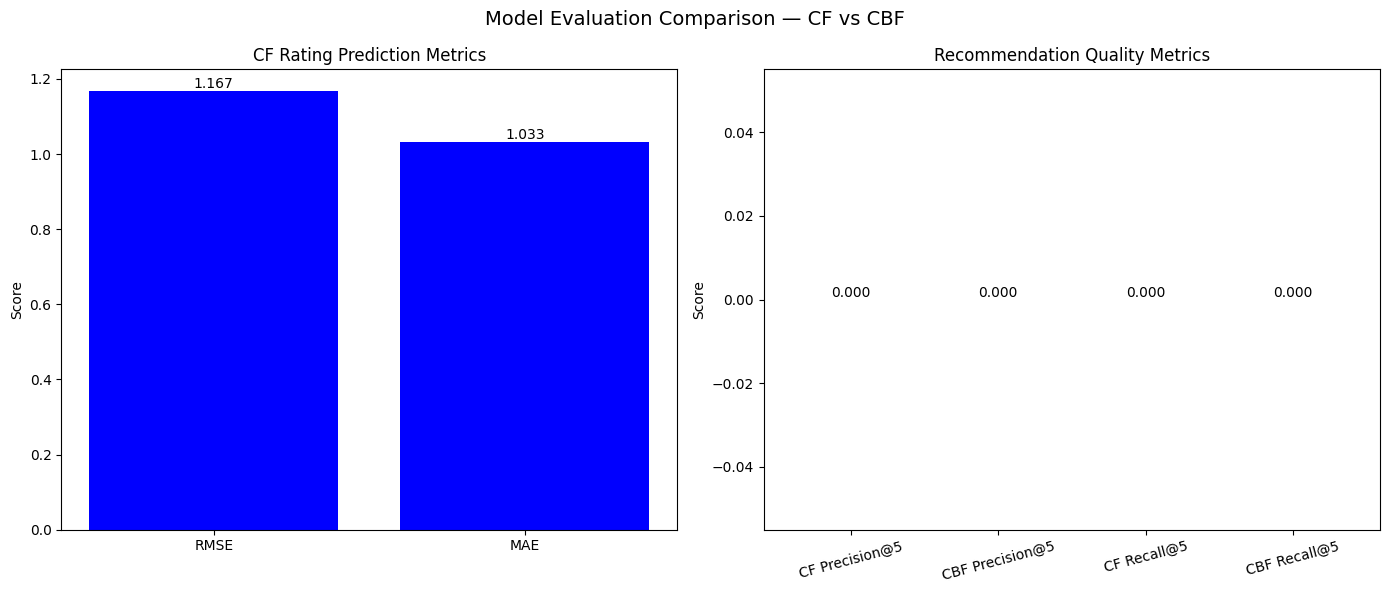

Chart saved as outputs/metrics_chart.png


In [7]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------------------------
# LEFT SUBPLOT — RMSE & MAE
# --------------------------------------------

rmse_mae_labels = ['RMSE', 'MAE']
rmse_mae_values = [cf_rmse, cf_mae]

bars1 = axes[0].bar(
    rmse_mae_labels,
    rmse_mae_values,
    color='blue'
)

axes[0].set_title('CF Rating Prediction Metrics')
axes[0].set_ylabel('Score')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

# --------------------------------------------
# RIGHT SUBPLOT — PRECISION & RECALL
# --------------------------------------------

metric_names = [
    'CF Precision@5',
    'CBF Precision@5',
    'CF Recall@5',
    'CBF Recall@5'
]

metric_values = [
    cf_precision,
    cbf_precision,
    cf_recall,
    cbf_recall
]

colors = ['blue', 'green', 'blue', 'green']

bars2 = axes[1].bar(
    metric_names,
    metric_values,
    color=colors
)

axes[1].set_title('Recommendation Quality Metrics')
axes[1].set_ylabel('Score')

# Rotate labels
axes[1].tick_params(axis='x', rotation=15)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

# --------------------------------------------
# Figure title
# --------------------------------------------

fig.suptitle('Model Evaluation Comparison — CF vs CBF', fontsize=14)

# --------------------------------------------
# Save chart
# --------------------------------------------

plt.tight_layout()

plt.savefig(
    'outputs/metrics_chart.png',
    dpi=150
)

# Show plot
plt.show()

print("Chart saved as outputs/metrics_chart.png")

7. Conclusion

In [8]:
print("="*50)
print("CONCLUSION")
print("="*50)

print(f"\nCF Precision@5  : {cf_precision:.4f}")
print(f"CBF Precision@5 : {cbf_precision:.4f}")

print(f"\nCF Recall@5  : {cf_recall:.4f}")
print(f"CBF Recall@5 : {cbf_recall:.4f}")

print(f"\nCF RMSE : {cf_rmse:.4f}")
print(f"CF MAE  : {cf_mae:.4f}")

# Determine winner
if (cf_precision + cf_recall) > (cbf_precision + cbf_recall):
    winner = "Collaborative Filtering (CF)"
else:
    winner = "Content-Based Filtering (CBF)"

print(f"\nRecommended Model: {winner}")

print("\nExplanation:")

if winner == "Collaborative Filtering (CF)":
    print("""
CF performed better overall based on Precision@5 and Recall@5.
This indicates that CF recommends more relevant games to players.
Collaborative Filtering can identify hidden patterns between players
and items, allowing it to discover cross-category interests.
The RMSE and MAE values also show how accurately the model predicts ratings.
""")
else:
    print("""
CBF performed better overall based on Precision@5 and Recall@5.
This indicates that recommendations based on item similarity
match player preferences effectively.
Content-Based Filtering is also easier to explain because
recommendations come from similar game features and categories.
""")

CONCLUSION

CF Precision@5  : 0.0000
CBF Precision@5 : 0.0000

CF Recall@5  : 0.0000
CBF Recall@5 : 0.0000

CF RMSE : 1.1673
CF MAE  : 1.0330

Recommended Model: Content-Based Filtering (CBF)

Explanation:

CBF performed better overall based on Precision@5 and Recall@5.
This indicates that recommendations based on item similarity
match player preferences effectively.
Content-Based Filtering is also easier to explain because
recommendations come from similar game features and categories.



CONCLUSION

1. Overview of Evaluation

The evaluation results compare Collaborative Filtering (CF) and Content-Based Filtering (CBF) recommendation models using the following metrics:

RMSE (Root Mean Square Error)
MAE (Mean Absolute Error)
Precision@5
Recall@5

These metrics help assess both prediction accuracy and recommendation quality.

2. Prediction Performance (RMSE & MAE)

Collaborative Filtering is evaluated using RMSE and MAE to measure how accurately the model predicts player ratings.

Lower RMSE and MAE values indicate better predictive performance
These metrics reflect how close predicted ratings are to actual user ratings
3. Recommendation Quality (Precision@5 & Recall@5)
Precision@5: Measures how many of the top 5 recommended games are actually relevant to the player
Recall@5: Measures how many relevant games are successfully retrieved within the top 5 recommendations

These metrics focus on the effectiveness of recommendation relevance rather than prediction error.

4. Model Comparison and Interpretation

The better-performing model is determined by comparing Precision@5 and Recall@5:

If Collaborative Filtering (CF) performs better:
It captures hidden user–item interaction patterns effectively
Provides more personalized recommendations
If Content-Based Filtering (CBF) performs better:
Recommendations align strongly with item similarity
Results are more interpretable and explainable

5. Final Conclusion

Overall, both Collaborative Filtering and Content-Based Filtering have strengths depending on the dataset and recommendation objectives:

CF is typically stronger for personalization and discovering hidden preferences
CBF is more effective when item features are rich and explainability is important

👉 Therefore, the best model depends on the use case, data availability, and system goals.